# 6. Nvidia-Unet-Diffusion-AI-model

Model Assessment by Nvidia, aiming to train a model that is able to generate handwritten images based on the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database). Traditionally, neural networks have a test dataset, but that is not necessarily the case with generative AI. Beauty is in the eye of the beholder, and it is up to you as the developer if overfitting is acceptable or not.

So instead, we have created a classifier model that has been trained on the MNIST dataset. It has an accuracy on the MNIST test dataset of over 99%. If this model can correctly identify 95% of your generated images, you will earn a certificate!

## 6.1 The Dataset

Let's get started, below are the libraries used in this assessment.

In [1]:
import glob
import math
import torch
import torch.nn.functional as F
import torch.nn as nn

from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms

from einops.layers.torch import Rearrange

# Visualization tools
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.utils import save_image, make_grid

# User defined libraries
from utils import other_utils
from utils import ddpm_utils
from utils import UNet_utils

# Best practise, use conditional device variable and .to(device) syntax
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device

In [2]:
#send to cpu or gpu
#model.to(device)
#model.cpu(), model.cuda()
#add the following in the function
#import pdb; pdb.set_trace()
!nvidia-smi

Wed Oct  8 12:06:17 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A10G         On   | 00000000:00:1E.0 Off |                    0 |
|  0%   30C    P8    16W / 300W |      2MiB / 23028MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

The FashionMnist dataset we used earlier is structurally similar to MNIST, so we will use much of the same code to load it. We will not randomly flip horizontally because numbers are not typically meant to be read backwards.

In [3]:
def load_MNIST(data_transform, train=True):
    return torchvision.datasets.MNIST(
        "./data/",
        download=True,
        train=train,
        transform=data_transform,
    )

def load_transformed_MNIST(img_size, batch_size):
    data_transforms = [
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),  # Scales data into [0,1]
    ]

    data_transform = transforms.Compose(data_transforms)
    train_set = load_MNIST(data_transform, train=True)
    test_set = load_MNIST(data_transform, train=False)
    data = torch.utils.data.ConcatDataset([train_set, test_set])
    dataloader = DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=True)
    return data, dataloader

The classifier model we will be challenging expects the image size to be `28 by 28` pixels. The images are also in black and white. There are `10` classes, one for each digit.

In [4]:
IMG_SIZE = 28
IMG_CH = 1
BATCH_SIZE = 128
N_CLASSES = 10
data, dataloader = load_transformed_MNIST(IMG_SIZE, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 6.2 Setting Up Diffusion

Let's begin by setting up the diffusion process. In the interest of time, we have already listed the recommended hyperparameters for the `Beta` schedule below.

In [5]:
nrows = 10
ncols = 15

T = nrows * ncols
B_start = 0.0001
B_end = 0.02
B = torch.linspace(B_start, B_end, T).to(device)

**TODO**: We still need to math out some of the variables we'll be using in our `q` and `reverse_q` function.  Can you replace the `FIXME`s below?

In [ ]:
a = 1.0 - B
a_bar = torch.cumprod(a, dim=0)
sqrt_a_bar = torch.sqrt(a_bar)  # Mean Coefficient
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar)  # St. Dev. Coefficient


# Reverse diffusion variables
sqrt_a_inv = torch.sqrt(1.0 / a)
pred_noise_coeff = (1.0 - a) / torch.sqrt(1.0 - a_bar)  # Predicted Noise Coefficient

We need to find the right ratio of image to noise. 

In [7]:
def q(x_0, t):
        t = t.int()
        noise = torch.randn_like(x_0)
        sqrt_a_bar_t = sqrt_a_bar[t, None, None, None]
        sqrt_one_minus_a_bar_t = sqrt_one_minus_a_bar[t, None, None, None]

        #x_t = FIXME * x_0 + FIXME * noise
        x_t = sqrt_a_bar_t * x_0 + sqrt_one_minus_a_bar_t * noise
        return x_t, noise

Please take a moment to verify the results are what you would expect. Does the image start clearly identifiable and then becomes lost in the noise?

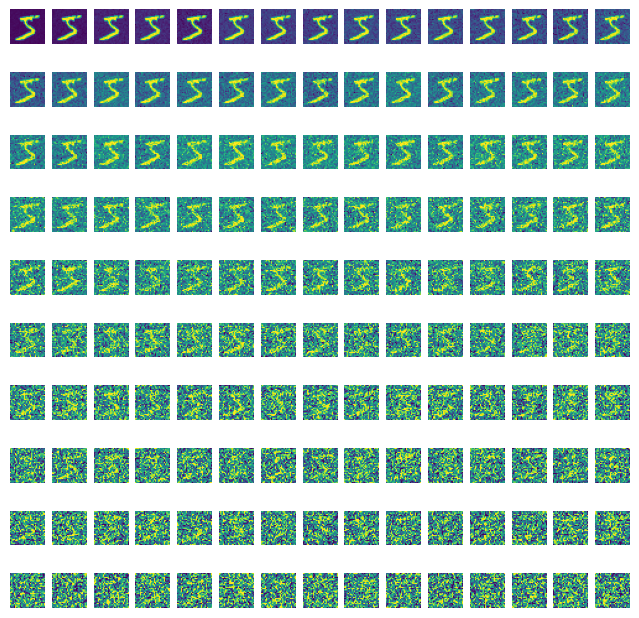

In [8]:
plt.figure(figsize=(8, 8))
x_0 = data[0][0].to(device)
xs = []

for t in range(T):
    t_tenser = torch.Tensor([t]).type(torch.int64)
    x_t, _ = q(x_0, t_tenser)
    img = torch.squeeze(x_t).cpu()
    xs.append(img)
    ax = plt.subplot(nrows, ncols, t + 1)
    ax.axis('off')
    other_utils.show_tensor_image(x_t)

**TODO**: The `reverse_q` function is mostly complete, but there are a few `FIXME`s. Each `FIXME` can be one of:
* `x_t` - the latent image
* `t` - the current timestep
* `e_t` - the predicted noise added at the current timestep

In [21]:
@torch.no_grad()
def reverse_q(x_t, t, e_t):
    # Accept t as either scalar tensor or 1D batch tensor
    # convert t to int tensor for indexing; ensure we use the scalar per-batch indexing below
    t_idx = t.int()
    # If t comes as a multi-dim tensor (e.g. shape (batch,1,1,1)) reduce to 1D for index
    # Get a per-sample index if batch; otherwise keep scalar.
    # We handle it by taking t_idx.flatten() if necessary when indexing arrays using advanced indexing.
    pred_noise_coeff_t = pred_noise_coeff[t_idx]  # broadcasting allowed
    sqrt_a_inv_t = sqrt_a_inv[t_idx]

    # mean term: 1/sqrt(alpha_t) * (x_t - (1-alpha_t)/sqrt(1-alpha_bar_t) * e_t)
    u_t = sqrt_a_inv_t * (x_t - pred_noise_coeff_t * e_t)

    # If all timesteps are zero (meaning we've reached t=0), return mean (no added noise).
    # We expect t to be a tensor; check all entries:
    if (t_idx == 0).all():
        return u_t
    else:
        # Add noise with beta from previous timestep
        B_t = B[t_idx - 1]
        new_noise = torch.randn_like(x_t)
        return u_t + torch.sqrt(B_t) * new_noise


## 6.3 Setting up a U-Net

We will be using the same U-Net architecture that we have previously used:

In [22]:
class UNet(nn.Module):
    def __init__(
        self, T, img_ch, img_size, down_chs=(64, 64, 128), t_embed_dim=8, c_embed_dim=10
    ):
        super().__init__()
        self.T = T
        up_chs = down_chs[::-1]  # Reverse of the down channels
        latent_image_size = img_size // 4  # 2 ** (len(down_chs) - 1)
        small_group_size = 8
        big_group_size = 32

        # Inital convolution
        self.down0 = ResidualConvBlock(img_ch, down_chs[0], small_group_size)

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1], big_group_size)
        self.down2 = DownBlock(down_chs[1], down_chs[2], big_group_size)
        self.to_vec = nn.Sequential(nn.Flatten(), nn.GELU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2] * latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2] * latent_image_size**2),
            nn.ReLU(),
        )
        self.sinusoidaltime = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_emb1 = EmbedBlock(t_embed_dim, up_chs[0])
        self.t_emb2 = EmbedBlock(t_embed_dim, up_chs[1])
        self.c_embed1 = EmbedBlock(c_embed_dim, up_chs[0])
        self.c_embed2 = EmbedBlock(c_embed_dim, up_chs[1])

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            GELUConvBlock(up_chs[0], up_chs[0], big_group_size),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1], big_group_size)
        self.up2 = UpBlock(up_chs[1], up_chs[2], big_group_size)

        # Match output channels and one last concatenation
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.GroupNorm(small_group_size, up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x, t, c, c_mask):
        down0 = self.down0(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        latent_vec = self.to_vec(down2)

        latent_vec = self.dense_emb(latent_vec)
        t = t.float() / self.T  # Convert from [0, T] to [0, 1]
        t = self.sinusoidaltime(t)
        t_emb1 = self.t_emb1(t)
        t_emb2 = self.t_emb2(t)

        c = c * c_mask
        c_emb1 = self.c_embed1(c)
        c_emb2 = self.c_embed2(c)

        up0 = self.up0(latent_vec)
        up1 = self.up1(c_emb1 * up0 + t_emb1, down2)
        up2 = self.up2(c_emb2 * up1 + t_emb2, down1)
        return self.out(torch.cat((up2, down0), 1))

Add the correct module name based on what the function is doing? There is one of each of:
* `GELUConvBlock`
* `RearrangePoolBlock`
* `DownBlock`
* `UpBlock`
* `SinusoidalPositionEmbedBlock`
* `EmbedBlock`
* `ResidualConvBlock`

In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super(DownBlock, self).__init__()
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            RearrangePoolBlock(out_chs, group_size),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [ ]:
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        super().__init__()
        self.rearrange = Rearrange("b c (h p1) (w p2) -> b (c p1 p2) h w", p1=2, p2=2)
        self.conv = GELUConvBlock(4 * in_chs, in_chs, group_size)

    def forward(self, x):
        x = self.rearrange(x)
        return self.conv(x)

In [ ]:
# ResidualConvBlock
class ResidualConvBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()
        self.conv1 = GELUConvBlock(in_chs, out_chs, group_size)
        self.conv2 = GELUConvBlock(out_chs, out_chs, group_size)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        out = x1 + x2
        return out

In [ ]:
# SinusoidalPositionEmbedBlock
class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [ ]:
# UpBlock
class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super(UpBlock, self).__init__()
        layers = [
            nn.ConvTranspose2d(2 * in_chs, out_chs, 2, 2),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

Now that all the pieces have been defined, let's define the model.

In [30]:
model = UNet(
    T, IMG_CH, IMG_SIZE, down_chs=(64, 64, 128), t_embed_dim=8, c_embed_dim=N_CLASSES
)
print("Num params: ", sum(p.numel() for p in model.parameters()))
model = torch.compile(model.to(device))

Num params:  2547457


## 6.4 Model Training

**TODO**: We should create a function to randomly drop the context. What was the function to do that?

In [ ]:
def get_context_mask(c, drop_prob):
    c_hot = F.one_hot(c.to(torch.int64), num_classes=N_CLASSES).to(device)
    # Bernoulli per-sample-per-class mask with keep probability (1 - drop_prob)
    #c_mask = torch.bernoulli(torch.ones_like(c_hot).float() * - drop_prob).to(device)
    c_mask = torch.bernoulli(torch.ones_like(c_hot).float() * (1.0 - drop_prob)).to(device)

    return c_hot, c_mask

**TODO**: Next, let's define the loss function. What type of loss function should we be using?

In [ ]:
def get_loss(model, x_0, t, *model_args):
    x_noisy, noise = q(x_0, t)
    noise_pred = model(x_noisy, t, *model_args)
    
    return F.mse_loss(noise, noise_pred)

This is mostly for our benefit to verify the model is training correctly.

In [33]:
def sample_images(model, img_ch, img_size, ncols, *model_args, axis_on=False):
    # Noise to generate images from
    x_t = torch.randn((1, img_ch, img_size, img_size), device=device)
    plt.figure(figsize=(8, 8))
    hidden_rows = T / ncols
    plot_number = 1

    # Go from T to 0 removing and adding noise until t = 0
    for i in range(0, T)[::-1]:
        t = torch.full((1,), i, device=device).float()
        e_t = model(x_t, t, *model_args)  # Predicted noise
        x_t = reverse_q(x_t, t, e_t)
        if i % hidden_rows == 0:
            ax = plt.subplot(1, ncols+1, plot_number)
            if not axis_on:
                ax.axis('off')
            other_utils.show_tensor_image(x_t.detach().cpu())
            plot_number += 1
    plt.show()

**TODO**: Time to train the model! Can you fix the `FIXME`s, and get it going?

Epoch 0 | Step 000 | Loss: 1.3401377201080322 | C: 0


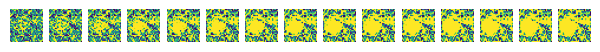

Epoch 0 | Step 100 | Loss: 0.09736430644989014 | C: 1


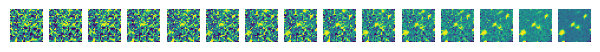

Epoch 0 | Step 200 | Loss: 0.08203679323196411 | C: 2


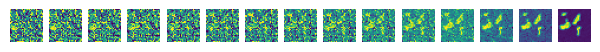

Epoch 0 | Step 300 | Loss: 0.055026207119226456 | C: 3


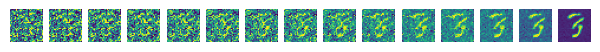

Epoch 0 | Step 400 | Loss: 0.053579192608594894 | C: 4


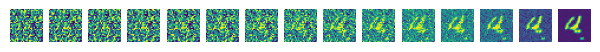

Epoch 0 | Step 500 | Loss: 0.04146040603518486 | C: 5


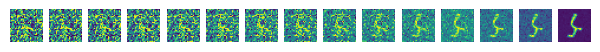

Epoch 1 | Step 000 | Loss: 0.04233454540371895 | C: 6


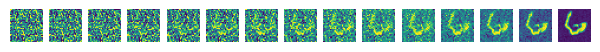

Epoch 1 | Step 100 | Loss: 0.049107298254966736 | C: 7


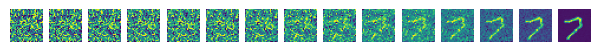

Epoch 1 | Step 200 | Loss: 0.04087424650788307 | C: 8


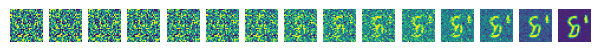

Epoch 1 | Step 300 | Loss: 0.042014267295598984 | C: 9


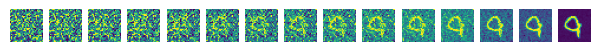

Epoch 1 | Step 400 | Loss: 0.047113362699747086 | C: 0


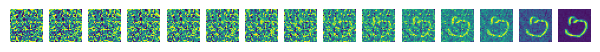

Epoch 1 | Step 500 | Loss: 0.038352541625499725 | C: 1


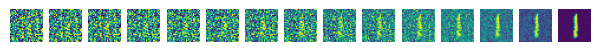

Epoch 2 | Step 000 | Loss: 0.03811749443411827 | C: 2


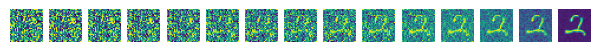

Epoch 2 | Step 100 | Loss: 0.03743124008178711 | C: 3


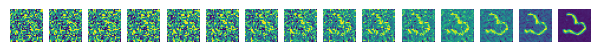

Epoch 2 | Step 200 | Loss: 0.034462012350559235 | C: 4


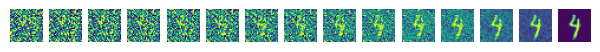

Epoch 2 | Step 300 | Loss: 0.038448818027973175 | C: 5


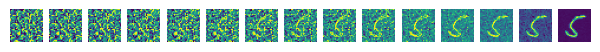

Epoch 2 | Step 400 | Loss: 0.036646436899900436 | C: 6


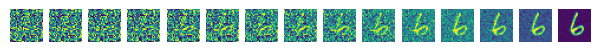

Epoch 2 | Step 500 | Loss: 0.035068728029727936 | C: 7


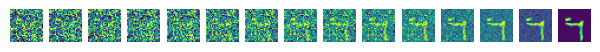

Epoch 3 | Step 000 | Loss: 0.04015304893255234 | C: 8


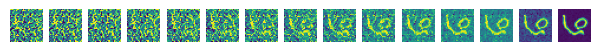

Epoch 3 | Step 100 | Loss: 0.03876806050539017 | C: 9


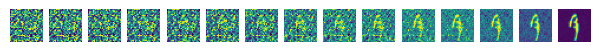

Epoch 3 | Step 200 | Loss: 0.04126882925629616 | C: 0


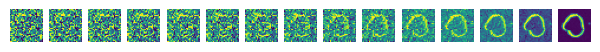

Epoch 3 | Step 300 | Loss: 0.03456975892186165 | C: 1


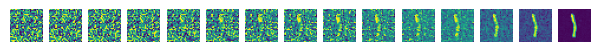

Epoch 3 | Step 400 | Loss: 0.03652307018637657 | C: 2


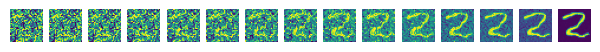

Epoch 3 | Step 500 | Loss: 0.04050913080573082 | C: 3


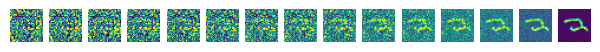

Epoch 4 | Step 000 | Loss: 0.03753260150551796 | C: 4


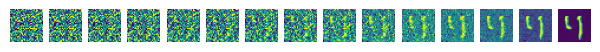

Epoch 4 | Step 100 | Loss: 0.041002918034791946 | C: 5


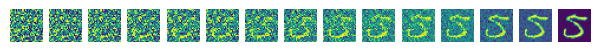

Epoch 4 | Step 200 | Loss: 0.0380982831120491 | C: 6


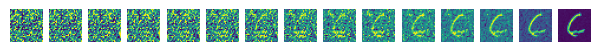

Epoch 4 | Step 300 | Loss: 0.03385967016220093 | C: 7


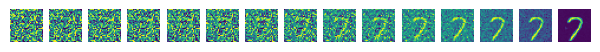

Epoch 4 | Step 400 | Loss: 0.03650732338428497 | C: 8


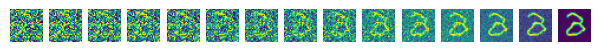

Epoch 4 | Step 500 | Loss: 0.03456808999180794 | C: 9


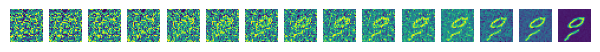

Epoch 5 | Step 000 | Loss: 0.03612610697746277 | C: 0


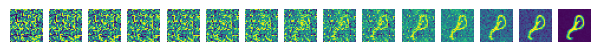

Epoch 5 | Step 100 | Loss: 0.035431042313575745 | C: 1


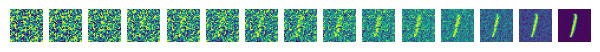

Epoch 5 | Step 200 | Loss: 0.03401457518339157 | C: 2


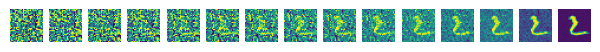

Epoch 5 | Step 300 | Loss: 0.04218459501862526 | C: 3


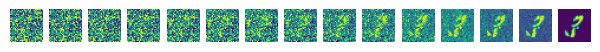

Epoch 5 | Step 400 | Loss: 0.031893711537122726 | C: 4


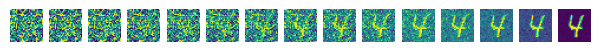

Epoch 5 | Step 500 | Loss: 0.03467109054327011 | C: 5


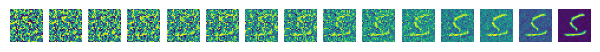

Epoch 6 | Step 000 | Loss: 0.029783539474010468 | C: 6


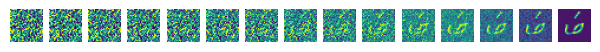

Epoch 6 | Step 100 | Loss: 0.037038158625364304 | C: 7


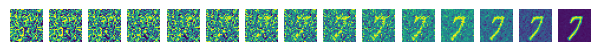

Epoch 6 | Step 200 | Loss: 0.03860799968242645 | C: 8


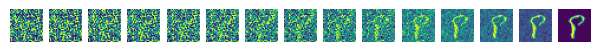

Epoch 6 | Step 300 | Loss: 0.034392740577459335 | C: 9


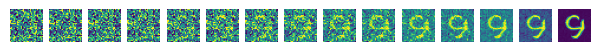

Epoch 6 | Step 400 | Loss: 0.03599007800221443 | C: 0


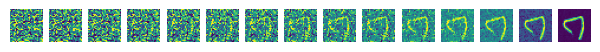

Epoch 6 | Step 500 | Loss: 0.03746788948774338 | C: 1


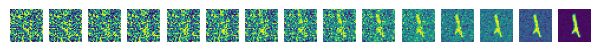

Epoch 7 | Step 000 | Loss: 0.035368435084819794 | C: 2


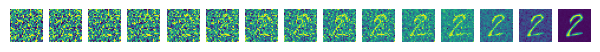

Epoch 7 | Step 100 | Loss: 0.04312483221292496 | C: 3


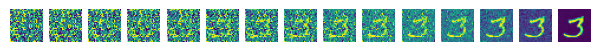

Epoch 7 | Step 200 | Loss: 0.028442133218050003 | C: 4


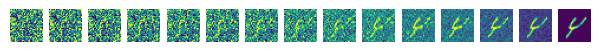

Epoch 7 | Step 300 | Loss: 0.03656873479485512 | C: 5


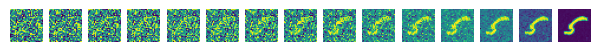

Epoch 7 | Step 400 | Loss: 0.03860201686620712 | C: 6


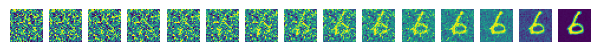

Epoch 7 | Step 500 | Loss: 0.03081951104104519 | C: 7


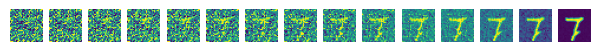

Epoch 8 | Step 000 | Loss: 0.034745000302791595 | C: 8


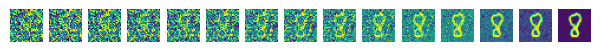

Epoch 8 | Step 100 | Loss: 0.03582673519849777 | C: 9


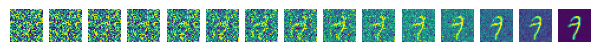

Epoch 8 | Step 200 | Loss: 0.027653099969029427 | C: 0


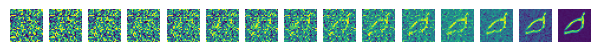

Epoch 8 | Step 300 | Loss: 0.029938027262687683 | C: 1


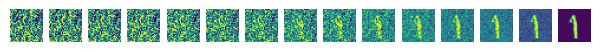

Epoch 8 | Step 400 | Loss: 0.03596259653568268 | C: 2


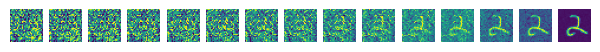

Epoch 8 | Step 500 | Loss: 0.03815112262964249 | C: 3


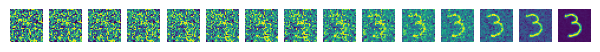

Epoch 9 | Step 000 | Loss: 0.029750661924481392 | C: 4


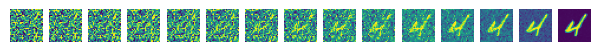

Epoch 9 | Step 100 | Loss: 0.032777901738882065 | C: 5


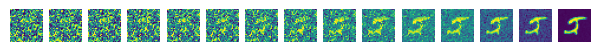

Epoch 9 | Step 200 | Loss: 0.032647036015987396 | C: 6


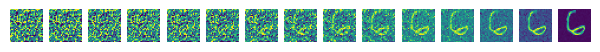

Epoch 9 | Step 300 | Loss: 0.0387582965195179 | C: 7


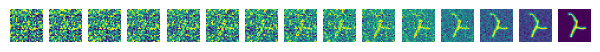

Epoch 9 | Step 400 | Loss: 0.03195898234844208 | C: 8


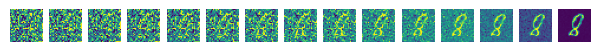

Epoch 9 | Step 500 | Loss: 0.03500328212976456 | C: 9


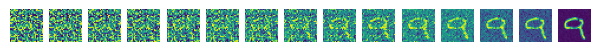

Epoch 10 | Step 000 | Loss: 0.03649323433637619 | C: 0


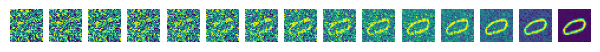

Epoch 10 | Step 100 | Loss: 0.03453115373849869 | C: 1


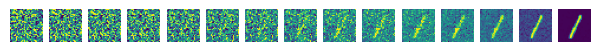

Epoch 10 | Step 200 | Loss: 0.02725405804812908 | C: 2


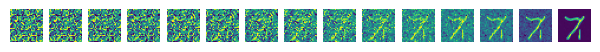

Epoch 10 | Step 300 | Loss: 0.03380022197961807 | C: 3


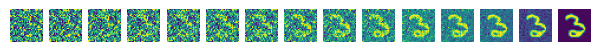

Epoch 10 | Step 400 | Loss: 0.033520810306072235 | C: 4


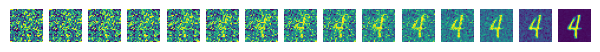

Epoch 10 | Step 500 | Loss: 0.03815599903464317 | C: 5


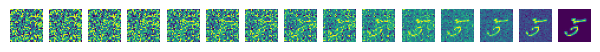

Epoch 11 | Step 000 | Loss: 0.031136395409703255 | C: 6


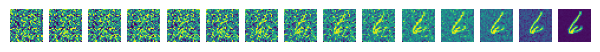

Epoch 11 | Step 100 | Loss: 0.03730911761522293 | C: 7


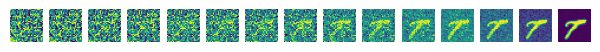

Epoch 11 | Step 200 | Loss: 0.03203713893890381 | C: 8


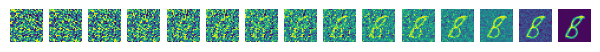

Epoch 11 | Step 300 | Loss: 0.03735426440834999 | C: 9


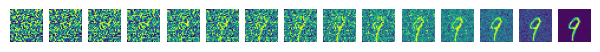

Epoch 11 | Step 400 | Loss: 0.038999591022729874 | C: 0


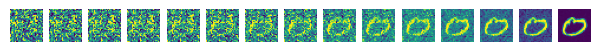

Epoch 11 | Step 500 | Loss: 0.034493133425712585 | C: 1


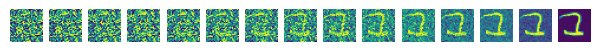

Epoch 12 | Step 000 | Loss: 0.0326143316924572 | C: 2


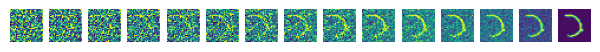

Epoch 12 | Step 100 | Loss: 0.03329357132315636 | C: 3


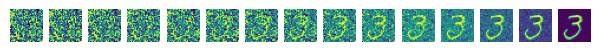

Epoch 12 | Step 200 | Loss: 0.037531495094299316 | C: 4


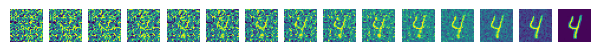

Epoch 12 | Step 300 | Loss: 0.03743939474225044 | C: 5


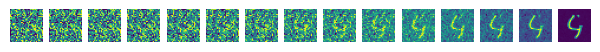

Epoch 12 | Step 400 | Loss: 0.03773890808224678 | C: 6


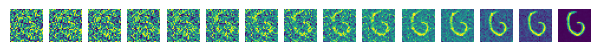

Epoch 12 | Step 500 | Loss: 0.03462081775069237 | C: 7


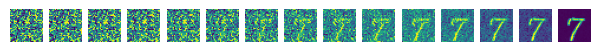

Epoch 13 | Step 000 | Loss: 0.03211439400911331 | C: 8


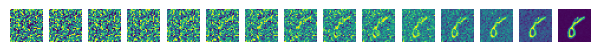

Epoch 13 | Step 100 | Loss: 0.031467657536268234 | C: 9


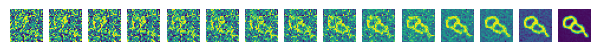

Epoch 13 | Step 200 | Loss: 0.03396066650748253 | C: 0


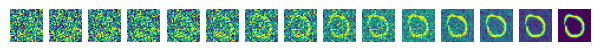

Epoch 13 | Step 300 | Loss: 0.03260977938771248 | C: 1


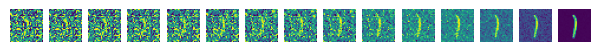

Epoch 13 | Step 400 | Loss: 0.030559642240405083 | C: 2


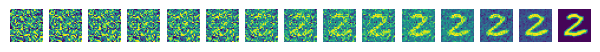

Epoch 13 | Step 500 | Loss: 0.0331839844584465 | C: 3


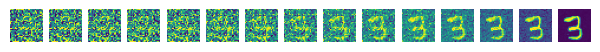

Epoch 14 | Step 000 | Loss: 0.031489040702581406 | C: 4


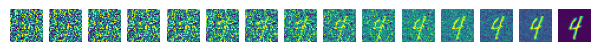

Epoch 14 | Step 100 | Loss: 0.034444425255060196 | C: 5


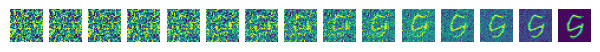

Epoch 14 | Step 200 | Loss: 0.03328700363636017 | C: 6


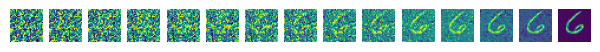

Epoch 14 | Step 300 | Loss: 0.033341746777296066 | C: 7


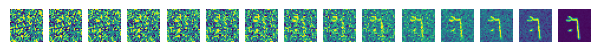

Epoch 14 | Step 400 | Loss: 0.03267727792263031 | C: 8


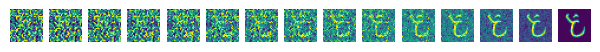

Epoch 14 | Step 500 | Loss: 0.035811614245176315 | C: 9


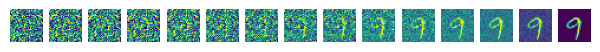

Epoch 15 | Step 000 | Loss: 0.03362424299120903 | C: 0


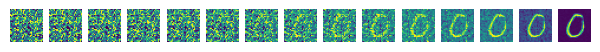

Epoch 15 | Step 100 | Loss: 0.03289417549967766 | C: 1


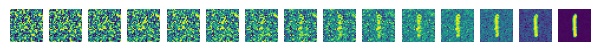

Epoch 15 | Step 200 | Loss: 0.03964176028966904 | C: 2


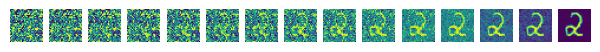

Epoch 15 | Step 300 | Loss: 0.029943842440843582 | C: 3


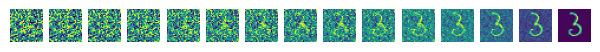

Epoch 15 | Step 400 | Loss: 0.03319057822227478 | C: 4


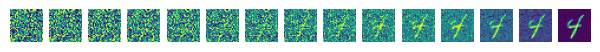

Epoch 15 | Step 500 | Loss: 0.035084787756204605 | C: 5


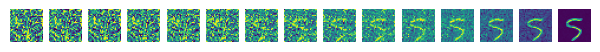

Epoch 16 | Step 000 | Loss: 0.03296837583184242 | C: 6


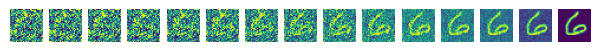

Epoch 16 | Step 100 | Loss: 0.03385210037231445 | C: 7


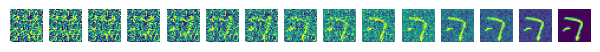

Epoch 16 | Step 200 | Loss: 0.035058312118053436 | C: 8


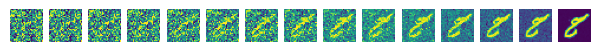

Epoch 16 | Step 300 | Loss: 0.029832100495696068 | C: 9


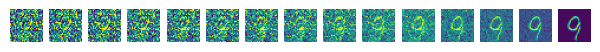

Epoch 16 | Step 400 | Loss: 0.031549401581287384 | C: 0


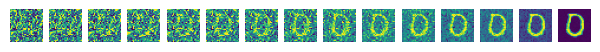

Epoch 16 | Step 500 | Loss: 0.03155079111456871 | C: 1


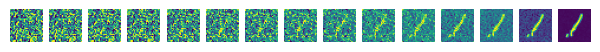

Epoch 17 | Step 000 | Loss: 0.03441179171204567 | C: 2


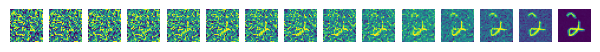

Epoch 17 | Step 100 | Loss: 0.029236145317554474 | C: 3


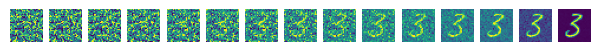

Epoch 17 | Step 200 | Loss: 0.03384912759065628 | C: 4


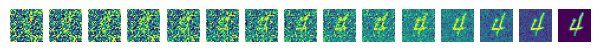

Epoch 17 | Step 300 | Loss: 0.033284448087215424 | C: 5


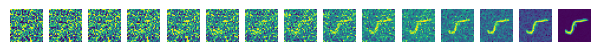

Epoch 17 | Step 400 | Loss: 0.033562805503606796 | C: 6


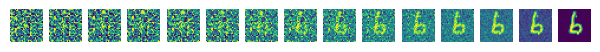

Epoch 17 | Step 500 | Loss: 0.03675154596567154 | C: 7


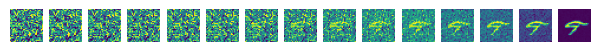

Epoch 18 | Step 000 | Loss: 0.037003643810749054 | C: 8


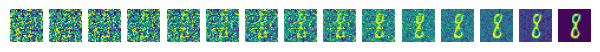

Epoch 18 | Step 100 | Loss: 0.030034322291612625 | C: 9


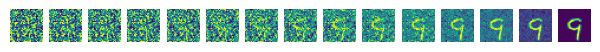

Epoch 18 | Step 200 | Loss: 0.03253656253218651 | C: 0


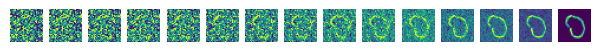

Epoch 18 | Step 300 | Loss: 0.03583964332938194 | C: 1


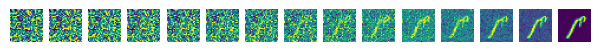

Epoch 18 | Step 400 | Loss: 0.032715555280447006 | C: 2


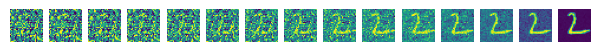

Epoch 18 | Step 500 | Loss: 0.0370379202067852 | C: 3


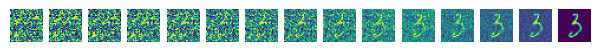

Epoch 19 | Step 000 | Loss: 0.03222997114062309 | C: 4


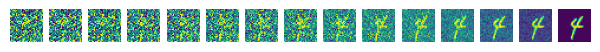

Epoch 19 | Step 100 | Loss: 0.0312986895442009 | C: 5


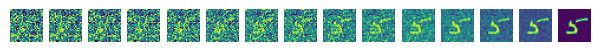

Epoch 19 | Step 200 | Loss: 0.030622446909546852 | C: 6


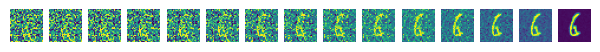

Epoch 19 | Step 300 | Loss: 0.034611620008945465 | C: 7


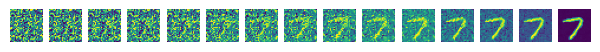

Epoch 19 | Step 400 | Loss: 0.031551484018564224 | C: 8


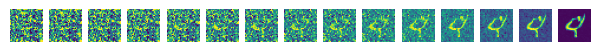

Epoch 19 | Step 500 | Loss: 0.03277390077710152 | C: 9


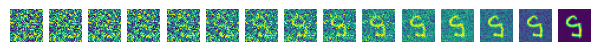

In [ ]:
optimizer = Adam(model.parameters(), lr=0.001)
#epochs = 5
epochs = 20
preview_c = 0

model.train()
for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
        #c_drop_prob = FIXME
         # probability of dropping context during training
        c_drop_prob = 0.1 # Drop context 10% of the time
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
        x = batch[0].to(device)
        #import pdb; pdb.set_trace()
        #c_hot, c_mask = get_context_mask(batch[1], c_drop_prob)
        labels = batch[1].to(device)
        c_hot, c_mask = get_context_mask(labels, c_drop_prob)  # New
        
        loss = get_loss(model, x, t, c_hot, c_mask)
        loss.backward()
        optimizer.step()

        if epoch % 1 == 0 and step % 100 == 0:
            print(f"Epoch {epoch} | Step {step:03d} | Loss: {loss.item()} | C: {preview_c}")
            c_drop_prob = 0 # Do not drop context for preview
            c_hot, c_mask = get_context_mask(torch.Tensor([preview_c]), c_drop_prob)
            sample_images(model, IMG_CH, IMG_SIZE, ncols, c_hot, c_mask)
            preview_c = (preview_c + 1) % N_CLASSES

## 6.5 Sampling

This is the last piece to the puzzle. We could compare the generator against the classifier, but as is, it would be extremely lucky to get over 95% accuracy. Let's use `Classifier-Free Diffusion Guidance to improve our chances.

Remember the formula to add weight to the diffusion process...

In [ ]:
@torch.no_grad()
def sample_w(model, c, w):
    input_size = (IMG_CH, IMG_SIZE, IMG_SIZE)
    n_samples = len(c)
    w = torch.tensor([w]).float()
    w = w[:, None, None, None].to(device)  # Make w broadcastable
    x_t = torch.randn(n_samples, *input_size).to(device)

    # One c for each w
    c = c.repeat(len(w), 1)

    # Double the batch
    c = c.repeat(2, 1)

    # Don't drop context at test time
    c_mask = torch.ones_like(c).to(device)
    c_mask[n_samples:] = 0.0

    x_t_store = []
    for i in range(0, T)[::-1]:
        # Duplicate t for each sample
        t = torch.tensor([i]).to(device)
        t = t.repeat(n_samples, 1, 1, 1)

        # Double the batch
        x_t = x_t.repeat(2, 1, 1, 1)
        t = t.repeat(2, 1, 1, 1)

        # Find weighted noise
        e_t = model(x_t, t, c, c_mask)
        e_t_keep_c = e_t[:n_samples]
        e_t_drop_c = e_t[n_samples:]
        # e_t_keep_c = conditioned predictions (first half)
        # e_t_drop_c = unconditioned predictions (second half)
        # perform: e = e_uncond + w * (e_cond - e_uncond)
        e_t = e_t_drop_c + w * (e_t_keep_c - e_t_drop_c)
        #e_t = (1 + w) * e_t_keep_c - w * e_t_drop_c
        # Deduplicate batch for reverse diffusion
        x_t = x_t[:n_samples]
        t = t[:n_samples]
        x_t = reverse_q(x_t, t, e_t)

    return x_t

**TODO**: Let's test it out. Try running the cell below a few times. Can you make it so that the numbers are consistently recognizable by changing `w`?

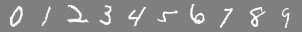

In [ ]:
model.eval()
w = 3.0
c = torch.arange(N_CLASSES).to(device)
c_drop_prob = 0 
c_hot, c_mask = get_context_mask(c, c_drop_prob)

x_0 = sample_w(model, c_hot, w)
other_utils.to_image(make_grid(x_0.cpu(), nrow=N_CLASSES))

This is important for the automated grader. Is the output shape `[10, 1, 28, 28]`? If yes, you're ready to test the model!

In [37]:
x_0.shape

torch.Size([10, 1, 28, 28])